
## Рабочая тетрадь №4


## Задания:

### 1. Для $ n $ точек напишите функцию прогноза линейной регрессии и визуализируйте линейную зависимость. Вычислите с помощью собственных функций:
- 
- Средние $ X, Y $;
- Ковариацию $ cov(X,Y) $;
- Коэффициенты $ \beta_1 $ и $ \beta_0 $.

Среднее X: 5.50, Среднее Y: 16.90
Ковариация: 16.39
Коэффициенты: beta_1 = 1.99, beta_0 = 5.97


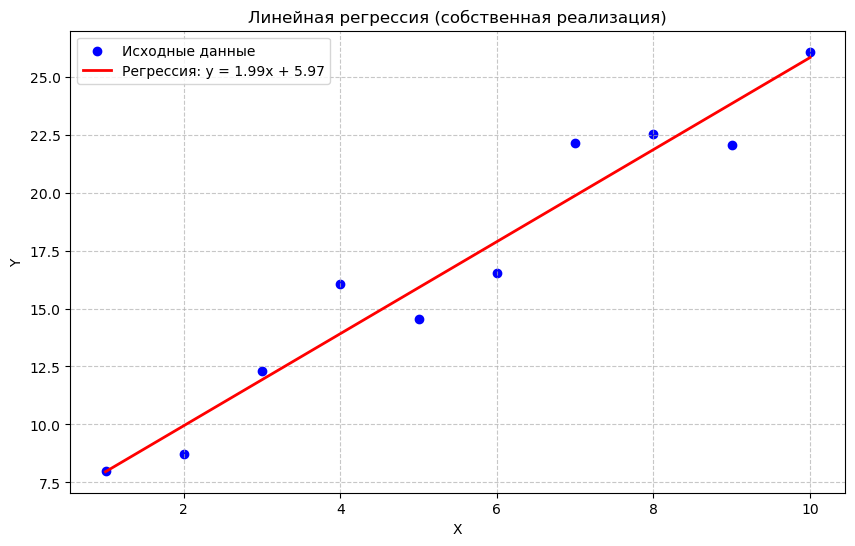

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def get_mean(data):
    return sum(data) / len(data)

def get_covariance(x, y, mu_x, mu_y):
    cov = 0
    for i in range(len(x)):
        cov += (x[i] - mu_x) * (y[i] - mu_y)
    return cov / len(x)

def get_variance(data, mu):
    return sum((xi - mu)**2 for xi in data) / len(data)

def linear_regression_fit(x, y):
    
    mu_x, mu_y = get_mean(x), get_mean(y)
    

    covariance = get_covariance(x, y, mu_x, mu_y)
    variance_x = get_variance(x, mu_x)
    
    beta_1 = covariance / variance_x
    beta_0 = mu_y - beta_1 * mu_x
    
    return beta_0, beta_1, mu_x, mu_y, covariance


np.random.seed(42)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

Y = 2 * X + 5 + np.random.normal(0, 2, len(X))


b0, b1, mean_x, mean_y, cov_xy = linear_regression_fit(X, Y)

print(f"Среднее X: {mean_x:.2f}, Среднее Y: {mean_y:.2f}")
print(f"Ковариация: {cov_xy:.2f}")
print(f"Коэффициенты: beta_1 = {b1:.2f}, beta_0 = {b0:.2f}")


def predict(x_val, b0, b1):
    return b0 + b1 * x_val


plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Исходные данные')
plt.plot(X, predict(X, b0, b1), color='red', linewidth=2, label=f'Регрессия: y = {b1:.2f}x + {b0:.2f}')

plt.title("Линейная регрессия (собственная реализация)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 2. Визуализируйте данные и $ \epsilon $-трубку вокруг линии $ \beta_1 x + \beta_0 $ с помощью собственных функций. Определите, какие точки являются:
- Внутри трубки;
- Опорными векторами;
- За пределами трубки.

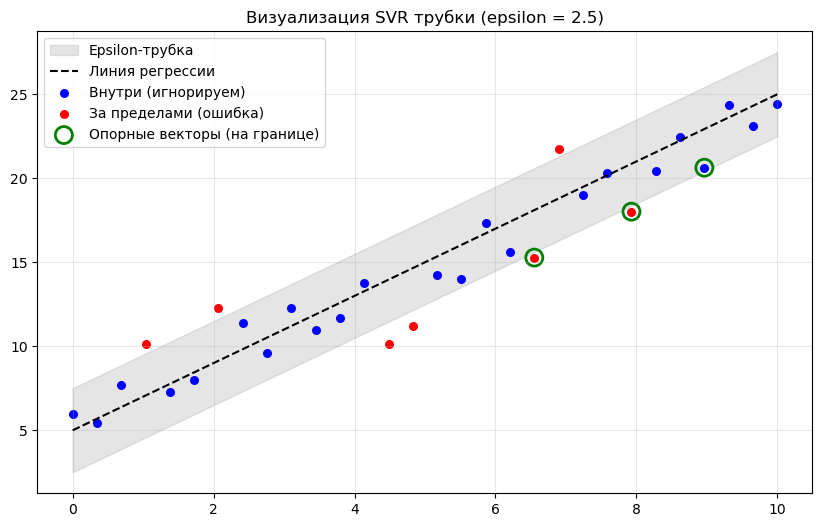

In [7]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
x = np.linspace(0, 10, 30)

y = 2 * x + 5 + np.random.normal(0, 2, len(x))


beta_1, beta_0 = 2.0, 5.0
epsilon = 2.5 


y_pred = beta_1 * x + beta_0
errors = np.abs(y - y_pred)


inside = errors < epsilon
outside = errors >= epsilon

support_idx = np.argsort(np.abs(errors - epsilon))[:3]


plt.figure(figsize=(10, 6))


plt.fill_between(x, y_pred - epsilon, y_pred + epsilon, color='gray', alpha=0.2, label='Epsilon-трубка')
plt.plot(x, y_pred, 'k--', label='Линия регрессии')


plt.scatter(x[inside], y[inside], c='blue', s=30, label='Внутри (игнорируем)')
plt.scatter(x[outside], y[outside], c='red', s=30, label='За пределами (ошибка)')
plt.scatter(x[support_idx], y[support_idx], edgecolors='green', facecolors='none', 
            s=150, linewidths=2, label='Опорные векторы (на границе)')

plt.title(f"Визуализация SVR трубки (epsilon = {epsilon})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3. Для матрицы признаков $ X $ и вектора отклика $ y $ выполните $ n $ шагов OMP. Найдите первый наиболее коррелированный признак. Рассчитайте остаток после m-ой итерации.

In [11]:
import numpy as np

def orthogonal_matching_pursuit(X, y, n_steps):
    n_samples, n_features = X.shape
    residual = y.copy()
    selected_indices = []
    
    
    X_norm = X / np.linalg.norm(X, axis=0)
    
    print(f"Исходная норма остатка: {np.linalg.norm(residual):.4f}\n")

    for step in range(1, n_steps + 1):
        correlations = np.abs(X_norm.T @ residual)
        best_feature_idx = np.argmax(correlations)
        
        if best_feature_idx not in selected_indices:
            selected_indices.append(best_feature_idx)
        
        
        X_S = X[:, selected_indices]

        beta = np.linalg.solve(X_S.T @ X_S, X_S.T @ y)
        
        residual = y - X_S @ beta
        
        print(f"Шаг {step}:")
        print(f"  Выбран признак индекс: {best_feature_idx}")
        print(f"  Норма остатка: {np.linalg.norm(residual):.4f}")
        
    return selected_indices, residual


np.random.seed(42)
X = np.random.randn(100, 10) 

y = 3 * X[:, 2] + 5 * X[:, 5] + np.random.normal(0, 0.1, 100)

indices, final_residual = orthogonal_matching_pursuit(X, y, n_steps=3)

Исходная норма остатка: 55.9093

Шаг 1:
  Выбран признак индекс: 5
  Норма остатка: 30.5647
Шаг 2:
  Выбран признак индекс: 2
  Норма остатка: 0.9532
Шаг 3:
  Выбран признак индекс: 6
  Норма остатка: 0.9407


### 4. Напишите собственные функции для регуляризации L2, L1 и sticNet.

In [13]:
import numpy as np

def get_l1_penalty(weights, l1_ratio):
    return l1_ratio * np.sign(weights)

def get_l2_penalty(weights, l2_ratio):

    return l2_ratio * 2 * weights

def elastic_net_step(X, y, weights, lr, l1_lambda, l2_lambda):

    n = len(y)
    predictions = X @ weights
    errors = predictions - y
    
   
    gradient = (2/n) * (X.T @ errors)
    
    
    l1_penalty = get_l1_penalty(weights, l1_lambda)
    l2_penalty = get_l2_penalty(weights, l2_lambda)
    
    total_gradient = gradient + l1_penalty + l2_penalty
    
 
    new_weights = weights - lr * total_gradient
    return new_weights


np.random.seed(42)
X = np.random.randn(100, 5)
y = X @ np.array([1, 0, 3, 0, 5]) + np.random.normal(0, 1, 100)
weights = np.zeros(5)


for _ in range(1000):
    weights = elastic_net_step(X, y, weights, lr=0.01, l1_lambda=0.1, l2_lambda=0.1)

print("Результирующие веса:", np.round(weights, 2))

Результирующие веса: [0.83 0.09 2.7  0.06 4.55]
